In [1]:
# ============================================================
# TASK 1 - PREDICTING HOUSE PRICES WITH LINEAR REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

df = pd.read_csv("../data/house_prices.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 1460
Columns: 82


,Unnamed: 0,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Dataset overview

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

Dataset Shape: (1460, 82)

Column Names:
['Unnamed: 0', 'Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedP

Unnamed: 0         int64
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 82, dtype: object

In [4]:
# Missing values analysis

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

display(missing_summary[missing_summary["Missing Values"] > 0])

,Missing Values,Missing Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageQual,81,5.55


In [5]:
# Descriptive statistics for numerical features

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"1,460.00",729.50,421.61,0.00,364.75,729.50,"1,094.25","1,459.00"
Id,"1,460.00",730.50,421.61,1.00,365.75,730.50,"1,095.25","1,460.00"
MSSubClass,"1,460.00",56.90,42.30,20.00,20.00,50.00,70.00,190.00
LotFrontage,"1,201.00",70.05,24.28,21.00,59.00,69.00,80.00,313.00
LotArea,"1,460.00","10,516.83","9,981.26","1,300.00","7,553.50","9,478.50","11,601.50","215,245.00"
OverallQual,"1,460.00",6.10,1.38,1.00,5.00,6.00,7.00,10.00
OverallCond,"1,460.00",5.58,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,"1,460.00","1,971.27",30.20,"1,872.00","1,954.00","1,973.00","2,000.00","2,010.00"
YearRemodAdd,"1,460.00","1,984.87",20.65,"1,950.00","1,967.00","1,994.00","2,004.00","2,010.00"
MasVnrArea,"1,452.00",103.69,181.07,0.00,0.00,0.00,166.00,"1,600.00"


In [6]:
# Target variable analysis

print("SalePrice Statistics:")
display(df["SalePrice"].describe())

print("\nMinimum Price:", df["SalePrice"].min())
print("Maximum Price:", df["SalePrice"].max())
print("Mean Price:", df["SalePrice"].mean())
print("Median Price:", df["SalePrice"].median())

SalePrice Statistics:


count     1,460.00
mean    180,921.20
std      79,442.50
min      34,900.00
25%     129,975.00
50%     163,000.00
75%     214,000.00
max     755,000.00
Name: SalePrice, dtype: float64


Minimum Price: 34900
Maximum Price: 755000
Mean Price: 180921.19589041095
Median Price: 163000.0


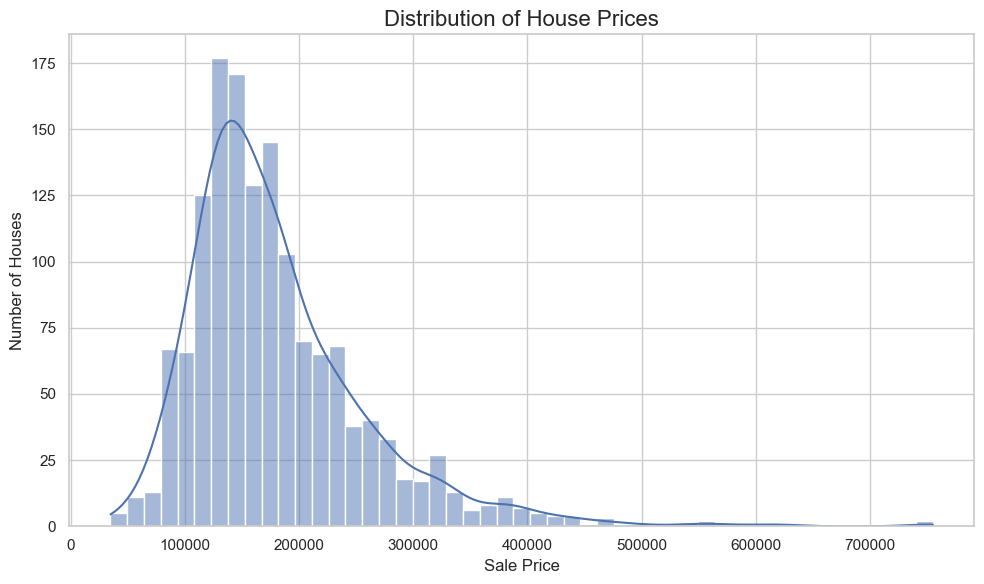

In [7]:
# Distribution of house prices

plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices", fontsize=16)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.savefig("../outputs/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

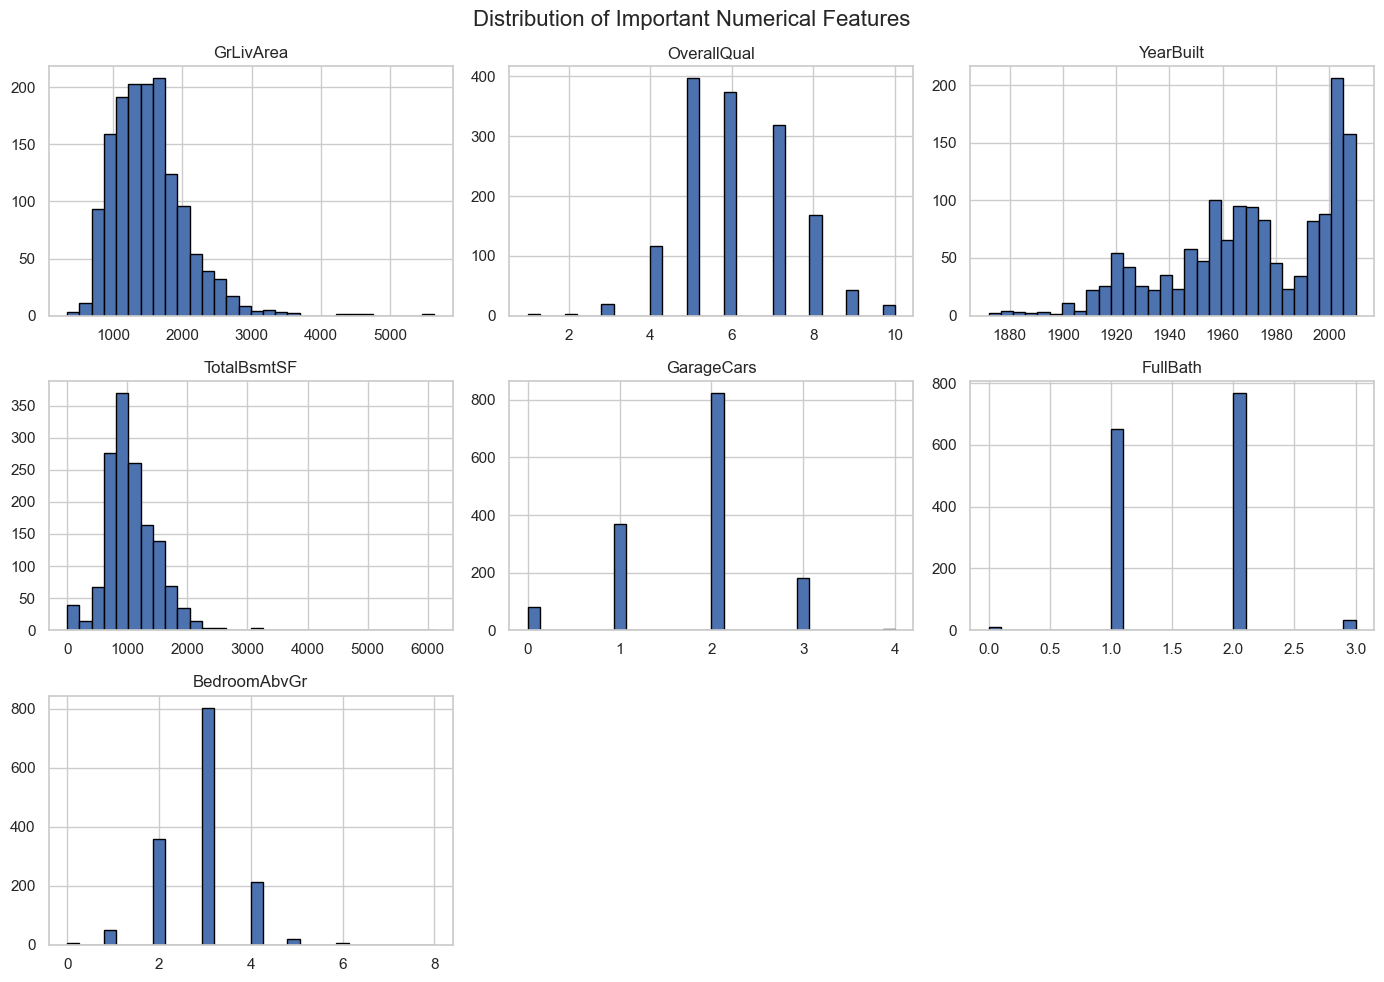

In [8]:
# Distribution of important numerical features

important_numeric_features = [
    "GrLivArea",
    "OverallQual",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "FullBath",
    "BedroomAbvGr"
]

df[important_numeric_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Important Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Feature Selection Discussion

For house price prediction, features related to house size, quality, location, age, and facilities are expected to be important predictors of the sale price.

The following features are selected because they have a logical relationship with house prices:

- **GrLivArea**: Larger above-ground living area generally increases house value.
- **OverallQual**: Higher overall quality is expected to have a strong positive effect on price.
- **YearBuilt**: Newer houses may have higher prices because of modern construction and features.
- **TotalBsmtSF**: Larger basement area can contribute to higher property value.
- **GarageCars**: Greater garage capacity may indicate a more valuable property.
- **FullBath**: The number of full bathrooms can influence buyer demand and price.
- **BedroomAbvGr**: The number of bedrooms is relevant to the functionality and size of a house.
- **Neighborhood**: Location is an important categorical factor because property values vary across neighborhoods.

These features provide a balance between numerical and categorical variables and allow us to demonstrate both numerical relationships and One-Hot Encoding in the machine learning pipeline.

In [9]:
# Remove unnecessary index column

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Updated dataset shape:", df.shape)

Updated dataset shape: (1460, 81)


In [10]:
# Select features for the model

selected_features = [
    "GrLivArea",
    "OverallQual",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "FullBath",
    "BedroomAbvGr",
    "Neighborhood"
]

target = "SalePrice"

model_df = df[selected_features + [target]].copy()

print("Selected features:")
print(selected_features)

print("\nModel dataset shape:", model_df.shape)

display(model_df.head())

Selected features:
['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 'FullBath', 'BedroomAbvGr', 'Neighborhood']

Model dataset shape: (1460, 9)


,GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,GarageCars,FullBath,BedroomAbvGr,Neighborhood,SalePrice
0,1710,7,2003,856,2,2,3,CollgCr,208500
1,1262,6,1976,1262,2,2,3,Veenker,181500
2,1786,7,2001,920,2,2,3,CollgCr,223500
3,1717,7,1915,756,3,1,3,Crawfor,140000
4,2198,8,2000,1145,3,2,4,NoRidge,250000


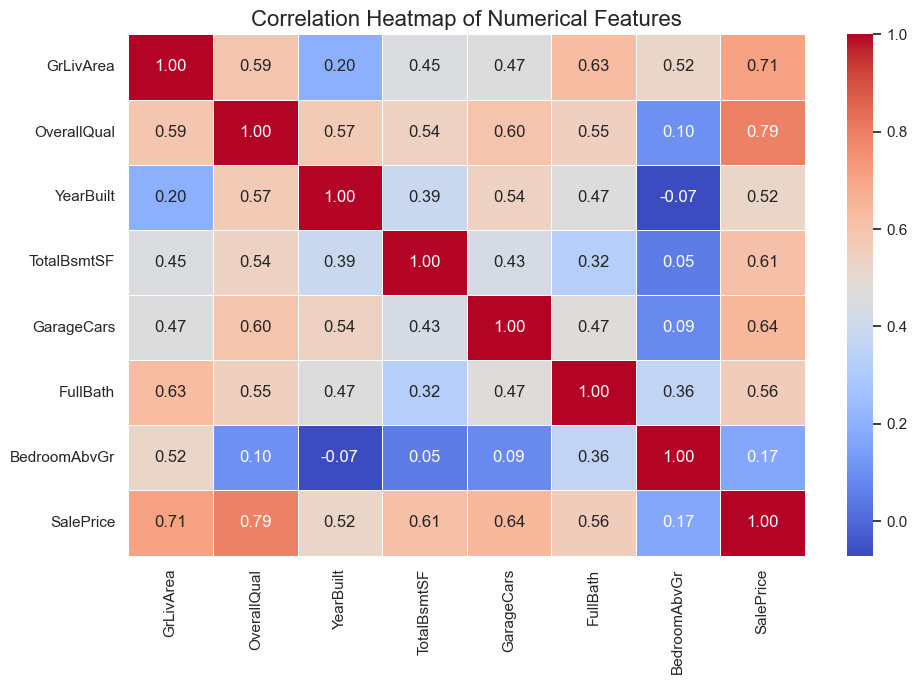

In [11]:
# Correlation analysis for numerical features

numeric_features = [
    "GrLivArea",
    "OverallQual",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "FullBath",
    "BedroomAbvGr",
    "SalePrice"
]

correlation_matrix = model_df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()

plt.savefig(
    "../outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Correlation of each numerical feature with house price

price_correlations = (
    correlation_matrix["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

display(price_correlations.to_frame(name="Correlation with SalePrice"))

,Correlation with SalePrice
OverallQual,0.79
GrLivArea,0.71
GarageCars,0.64
TotalBsmtSF,0.61
FullBath,0.56
YearBuilt,0.52
BedroomAbvGr,0.17


In [13]:
# Separate features and target

X = model_df[selected_features]
y = model_df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features shape: (1460, 8)
Target shape: (1460,)


,GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,GarageCars,FullBath,BedroomAbvGr,Neighborhood
0,1710,7,2003,856,2,2,3,CollgCr
1,1262,6,1976,1262,2,2,3,Veenker
2,1786,7,2001,920,2,2,3,CollgCr
3,1717,7,1915,756,3,1,3,Crawfor
4,2198,8,2000,1145,3,2,4,NoRidge


In [14]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [15]:
# Identify numerical and categorical columns

categorical_features = ["Neighborhood"]

numerical_features = [
    "GrLivArea",
    "OverallQual",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "FullBath",
    "BedroomAbvGr"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 'FullBath', 'BedroomAbvGr']

Categorical features:
['Neighborhood']


In [16]:
# Preprocessing pipelines

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [18]:
# Preprocessing pipelines

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [19]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully!")

Linear Regression pipeline created successfully!


In [20]:
# Make predictions on the test set

y_pred = linear_regression_model.predict(X_test)

print("Predictions generated successfully!")

display(
    pd.DataFrame({
        "Actual Price": y_test.values[:10],
        "Predicted Price": y_pred[:10]
    })
)

NotFittedError: Pipeline is not fitted yet.

In [21]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully!")

Linear Regression pipeline created successfully!


In [22]:
linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
y_pred = linear_regression_model.predict(X_test)

print("Predictions generated successfully!")

display(
    pd.DataFrame({
        "Actual Price": y_test.values[:10],
        "Predicted Price": y_pred[:10]
    })
)

Predictions generated successfully!


,Actual Price,Predicted Price
0,154500,"140,741.51"
1,325000,"328,889.85"
2,115000,"114,611.26"
3,159000,"180,140.43"
4,315500,"284,697.38"
5,75500,"62,215.28"
6,311500,"228,532.65"
7,146000,"152,353.72"
8,84500,"61,688.33"
9,135500,"124,153.99"


In [24]:
# Model Evaluation

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("=" * 45)
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
MSE  : 1,301,513,687.00
RMSE : 36,076.50
R²   : 0.8303


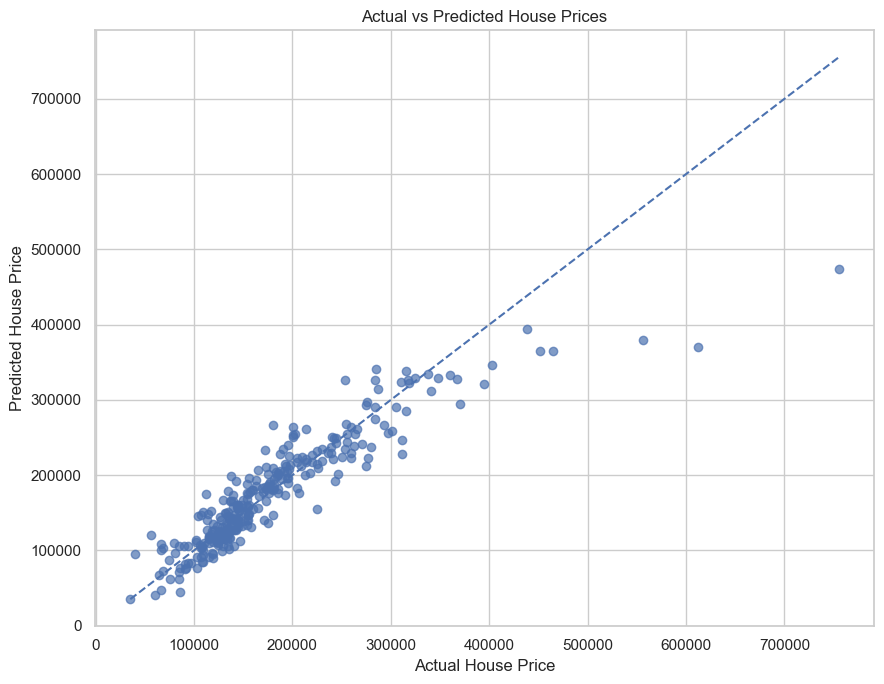

In [25]:
# Actual vs Predicted Prices

plt.figure(figsize=(9, 7))

plt.scatter(y_test, y_pred, alpha=0.7)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

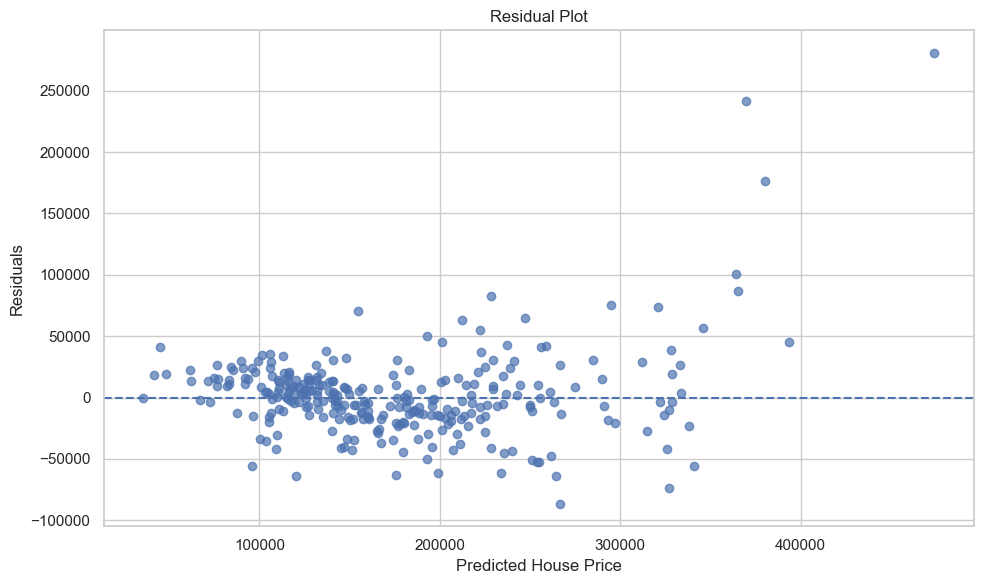

In [26]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    "../outputs/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Coefficient Analysis

preprocessor_fitted = linear_regression_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

coefficients = linear_regression_model.named_steps["model"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficient_df.head(15))

,Feature,Coefficient,Absolute_Coefficient
29,cat__Neighborhood_StoneBr,"48,570.22","48,570.22"
23,cat__Neighborhood_NridgHt,"46,950.31","46,950.31"
22,cat__Neighborhood_NoRidge,"45,521.11","45,521.11"
8,cat__Neighborhood_Blueste,"-40,151.62","40,151.62"
9,cat__Neighborhood_BrDale,"-38,082.73","38,082.73"
31,cat__Neighborhood_Veenker,"37,549.42","37,549.42"
7,cat__Neighborhood_Blmngtn,"-26,069.75","26,069.75"
11,cat__Neighborhood_ClearCr,"25,602.71","25,602.71"
20,cat__Neighborhood_NPkVill,"-23,345.28","23,345.28"
13,cat__Neighborhood_Crawfor,"21,941.27","21,941.27"


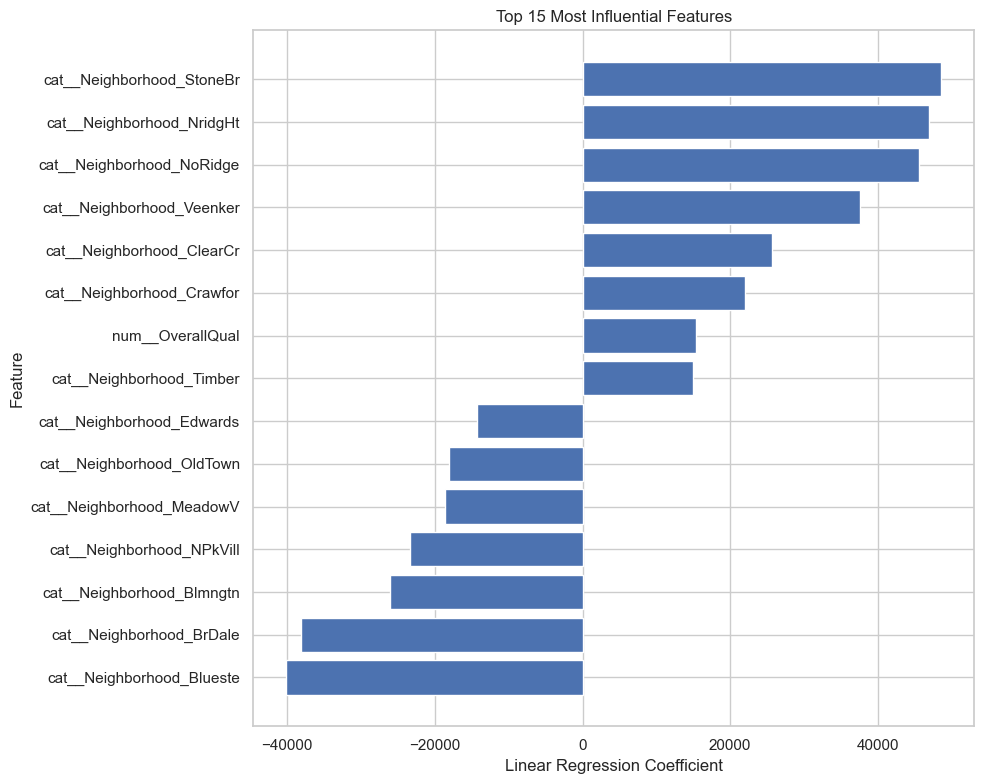

In [28]:
# Top 15 Most Influential Features

top_coefficients = (
    coefficient_df
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Most Influential Features")

plt.tight_layout()

plt.savefig(
    "../outputs/coefficient_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Ridge Regression

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("=" * 45)
print(f"MSE  : {ridge_mse:,.2f}")
print(f"RMSE : {ridge_rmse:,.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression
MSE  : 1,300,277,978.51
RMSE : 36,059.37
R²   : 0.8305


In [30]:
# Lasso Regression

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=100.0, max_iter=10000))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("=" * 45)
print(f"MSE  : {lasso_mse:,.2f}")
print(f"RMSE : {lasso_rmse:,.2f}")
print(f"R²   : {lasso_r2:.4f}")

Lasso Regression
MSE  : 1,301,882,351.90
RMSE : 36,081.61
R²   : 0.8303


In [31]:
# Final Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison = model_comparison.sort_values(
    "R2 Score",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,MSE,RMSE,R2 Score
0,Ridge Regression,"1,300,277,978.51","36,059.37",0.83
1,Linear Regression,"1,301,513,687.00","36,076.50",0.83
2,Lasso Regression,"1,301,882,351.90","36,081.61",0.83


# Conclusion

This project developed an end-to-end house price prediction system using Linear Regression.

The Ames Housing dataset was explored through descriptive statistics, missing-value analysis, feature distributions, and correlation analysis. Relevant numerical and categorical features were selected based on their expected relationship with house prices.

Missing numerical values were handled using median imputation, while missing categorical values were handled using the most frequent category. The Neighborhood feature was converted into numerical features using One-Hot Encoding.

The dataset was divided into training and testing sets using an 80/20 split. A Linear Regression model was trained and evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

The Actual vs Predicted plot was used to visually assess prediction accuracy, while the residual plot was used to examine whether prediction errors showed systematic patterns. Coefficient analysis was performed to identify features with relatively stronger positive and negative effects on the predicted house price.

Ridge and Lasso Regression were also evaluated as regularized alternatives to Linear Regression. Their performance was compared using MSE, RMSE, and R² score. The model with the lowest RMSE and highest R² score provides the strongest performance on the test set.

Overall, the project demonstrates a complete machine learning workflow, including data cleaning, exploratory data analysis, feature selection, preprocessing, categorical encoding, model training, evaluation, visualization, and model interpretation.